# Vehicle Counting from Video - 02: Counting

Run the full counter: per-lane state machine that counts a blob once when it crosses the line, and re-arms when the lane empties so the next vehicle is counted too.

In [1]:
import sys, cv2, numpy as np
import matplotlib.pyplot as plt
sys.path.append('.')
import utils
frames=utils.load_frames(); LINE_Y=180
count, overlays = utils.count_vehicles(frames, line_y=LINE_Y)
gt=utils.ground_truth()
print('DETECTED %d vehicles / ground truth %d' % (count, gt))
print('accuracy: %.0f%%' % (100*min(count,gt)/max(count,gt)))

DETECTED 8 vehicles / ground truth 8
accuracy: 100%


## 1. Overlay frames (green boxes, red line, running count)

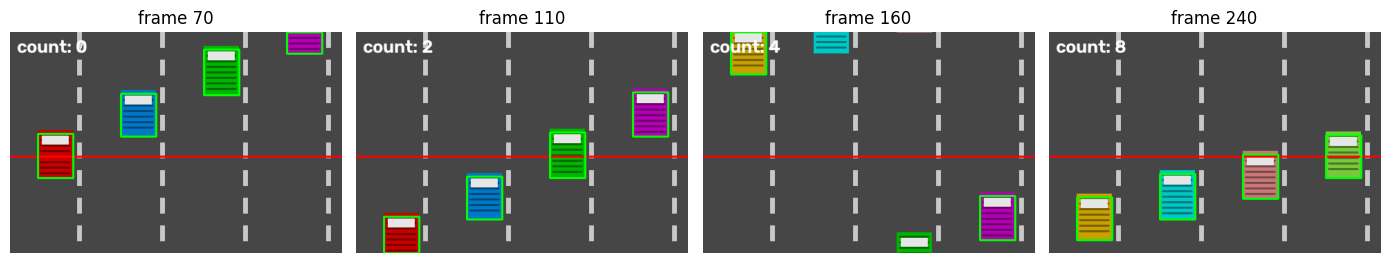

In [2]:
idx=[70,110,160,240]
fig,ax=plt.subplots(1,4,figsize=(14,3))
for a,i in zip(ax,idx): a.imshow(utils.to_rgb(overlays[i])); a.set_title('frame %d'%i); a.axis('off')
plt.tight_layout(); plt.show()

## 2. The final frame

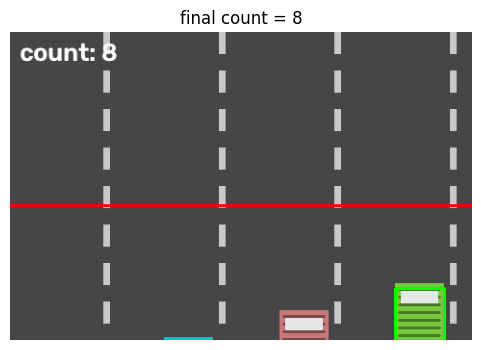

In [3]:
plt.figure(figsize=(6,4)); plt.imshow(utils.to_rgb(overlays[-1])); plt.title('final count = %d'%count); plt.axis('off'); plt.show()

### Finding
The counter recovers **all 8** vehicles exactly (8/8) on the synthetic clip. The approach is the standard classic-CV traffic-counting pipeline: background subtraction to isolate motion, a line-crossing rule to count. On real footage you would add shadow handling and a stronger tracker for occlusion, but the counting logic is the same.